# 07 — Scenario Analysis & Traceability Report\n\nEvaluate each scenario on Impact, Probability, and Confidence.\nVisualize as Impact vs Probability matrix with confidence overlay.\nGenerate full traceability report for top scenarios.

In [1]:
import sys, os, json
import matplotlib.pyplot as plt
import numpy as np
sys.path.insert(0, os.path.abspath(".."))

from src.config import CHROMA_PERSIST_DIR
from src.llm import embed, safe_chat_json
from src.traceability import Scenario, Assessment, TechDriver, DriverConfidence
from src import prompts

import chromadb
client = chromadb.PersistentClient(path=CHROMA_PERSIST_DIR)
collection = client.get_collection("knowledge_base")

with open("../data/outputs/scenario_state.json") as f:
    scenarios = [Scenario(**s) for s in json.load(f)["scenarios"]]
with open("../data/outputs/merge_state.json") as f:
    drivers = [TechDriver(**d) for d in json.load(f)["unified_drivers"]]
with open("../data/outputs/kb_state.json") as f:
    kb_state = json.load(f)

driver_by_id = {d.id: d for d in drivers}
print(f"Analyzing {len(scenarios)} scenarios")

Analyzing 6 scenarios


In [2]:
# compute confidence per scenario from driver confidences
conf_map = {"high": 0.9, "medium": 0.6, "low": 0.3}
scenario_confidences = []
for scenario in scenarios:
    driver_confs = []
    for a in scenario.assumptions:
        d = driver_by_id.get(a.driver_id)
        if d:
            driver_confs.append(conf_map.get(d.confidence.value, 0.5))
    scenario_confidences.append(round(np.mean(driver_confs), 2) if driver_confs else 0.5)

# build batch prompt with all scenarios (include perspective + type for richer eval)
scenarios_block_parts = []
for i, scenario in enumerate(scenarios):
    assumptions_text = "\n".join([f"  - {a.description}" for a in scenario.assumptions])
    perspective_line = f"\nPerspective: {scenario.perspective}" if scenario.perspective else ""
    tensions_line = f"\nKey tensions: {', '.join(scenario.key_tensions)}" if scenario.key_tensions else ""
    scenarios_block_parts.append(
        f"### Scenario {i}: {scenario.title}\n"
        f"Type: {scenario.type.value}{perspective_line}{tensions_line}\n"
        f"Assumptions:\n{assumptions_text}\n"
        f"Narrative (excerpt): {scenario.narrative[:600]}"
    )
scenarios_block = "\n\n".join(scenarios_block_parts)

# RAG: retrieve context using combined scenario queries
combined_query = " ".join([s.title for s in scenarios])
query_emb = embed([combined_query[:500]])[0]
rag = collection.query(query_embeddings=[query_emb], n_results=5, include=["documents", "metadatas"])
rag_text = "\n\n---\n\n".join([
    f"[Chunk ID: {rag['ids'][0][i]}] (Source: {rag['metadatas'][0][i]['source_title']})\n{rag['documents'][0][i]}"
    for i in range(len(rag["ids"][0]))
])

prompt = prompts.SCENARIO_ASSESS.format(
    n=len(scenarios),
    scenarios_block=scenarios_block,
    rag_chunks=rag_text,
)
result = safe_chat_json(prompt, system="You are a strategic technology analyst at Rohde & Schwarz evaluating future scenarios for spectrum monitoring.")

# parse batch results into Assessment objects
assessments: list[Assessment] = []
batch_assessments = result.get("assessments", [])

for i, scenario in enumerate(scenarios):
    match = next((a for a in batch_assessments if a.get("scenario_index") == i), None)
    if match:
        impact = match.get("impact", 5)
        probability = match.get("probability", 5)
        reasoning = match.get("reasoning", "")
        key_risks = match.get("key_risks", "")
        early_signals = match.get("early_signals", "")
        actionability = match.get("actionability", "")
        source_ids = match.get("source_chunk_ids_used", [])
    else:
        impact, probability, reasoning, key_risks, early_signals, actionability, source_ids = 5, 5, "No assessment returned", "", "", "", []

    assessment = Assessment(
        scenario_id=scenario.id,
        impact=impact,
        probability=probability,
        confidence=scenario_confidences[i],
        reasoning=reasoning,
        key_risks=key_risks,
        early_signals=early_signals,
        source_chunk_ids=source_ids,
    )
    assessments.append(assessment)

    print(f"  [{scenario.type.value:12s}] {scenario.title}")
    print(f"    Impact: {assessment.impact:.1f} | Prob: {assessment.probability:.1f} | Conf: {assessment.confidence:.2f}")
    print(f"    Risks: {key_risks[:80]}")
    print(f"    Signals: {early_signals[:80]}")
    print(f"    Action: {actionability[:80]}")
    print()

  [evolutionary] Incremental Integration and Persistent Complexity in 2035 Spectrum Monitoring
    Impact: 4.0 | Prob: 9.0 | Conf: 0.60
    Risks: Persistent complexity and mild incompatibilities between modules may slow integr
    Signals: Steady improvements in AI-native 6G deployments, gradual adoption of photonic si
    Action: Invest in modular, interoperable architectures supporting AI-native sensing and 

  [disruptive  ] Quantum Leap: Enforcing Spectrum Sovereignty through Atomic Precision in 2035
    Impact: 9.0 | Prob: 5.0 | Conf: 0.60
    Risks: Rapid obsolescence of classical systems could disrupt existing product lines. Ba
    Signals: Demonstrations of room-temperature quantum RF sensors, breakthroughs in federate
    Action: Invest in R&D for quantum sensing integration and federated AI architectures. De

  [cautionary  ] Stalled Spectrum Oversight: How Regulatory Gridlock Undermined 2035 Monitoring Advances
    Impact: 3.0 | Prob: 4.0 | Conf: 0.60
    Risks: Regulatory 

## Impact vs Probability Matrix

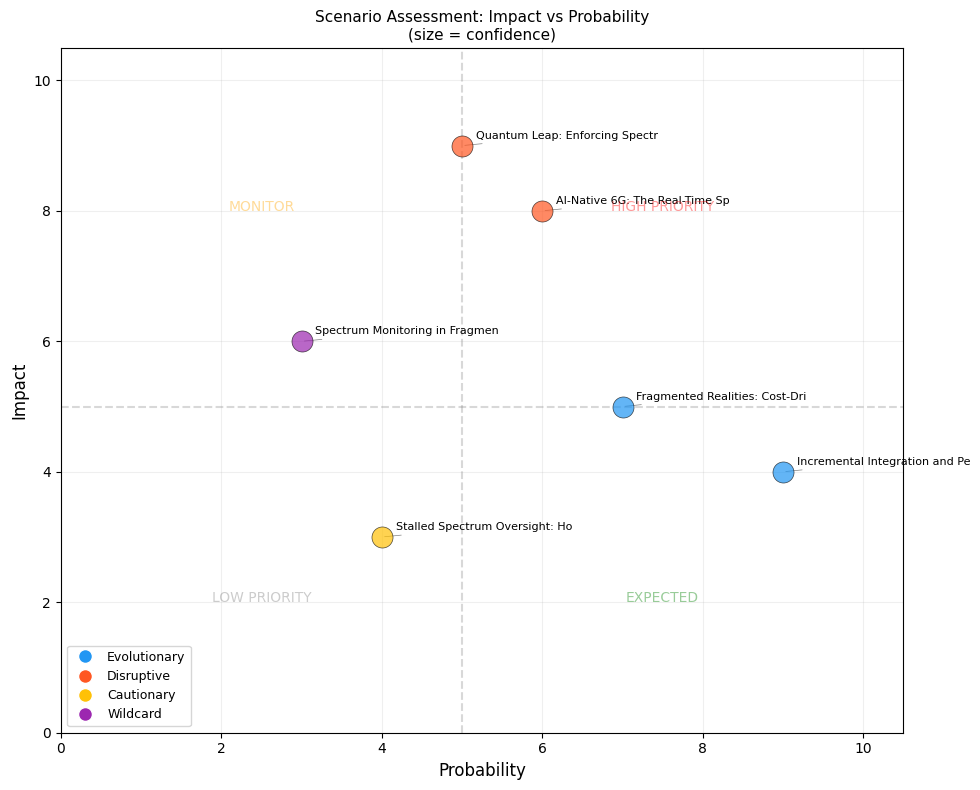

In [3]:
fig, ax = plt.subplots(figsize=(10, 8))

type_colors = {
    "evolutionary": "#2196F3",
    "disruptive": "#FF5722",
    "cautionary": "#FFC107",
    "wildcard": "#9C27B0",
}

for scenario, assessment in zip(scenarios, assessments):
    color = type_colors.get(scenario.type.value, "#999999")
    size = assessment.confidence * 300 + 50
    alpha = 0.4 + assessment.confidence * 0.5

    ax.scatter(assessment.probability, assessment.impact, s=size, c=color,
               alpha=alpha, edgecolors="black", linewidth=0.5, zorder=5)
    ax.annotate(scenario.title[:30], (assessment.probability, assessment.impact),
                textcoords="offset points", xytext=(10, 5), fontsize=8,
                arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

ax.set_xlim(0, 10.5)
ax.set_ylim(0, 10.5)
ax.set_xlabel("Probability", fontsize=12)
ax.set_ylabel("Impact", fontsize=12)
ax.set_title("Scenario Assessment: Impact vs Probability\n(size = confidence)", fontsize=11)
ax.axhline(y=5, color="gray", linestyle="--", alpha=0.3)
ax.axvline(x=5, color="gray", linestyle="--", alpha=0.3)
ax.text(7.5, 8, "HIGH PRIORITY", ha="center", fontsize=10, color="red", alpha=0.4)
ax.text(2.5, 8, "MONITOR", ha="center", fontsize=10, color="orange", alpha=0.4)
ax.text(7.5, 2, "EXPECTED", ha="center", fontsize=10, color="green", alpha=0.4)
ax.text(2.5, 2, "LOW PRIORITY", ha="center", fontsize=10, color="gray", alpha=0.4)

# legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=t.capitalize())
    for t, c in type_colors.items()
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("../data/outputs/scenario_matrix.png", dpi=150)
plt.show()

## Traceability Report

In [4]:
# full traceability report: for each scenario, trace back to original sources
source_by_id = kb_state["sources"]
chunk_by_id = kb_state["chunks"]

print("=" * 70)
print("TRACEABILITY REPORT — E2E Chain for Each Scenario")
print("=" * 70)

for scenario, assessment in zip(scenarios, assessments):
    print(f"\n{'─' * 70}")
    print(f"SCENARIO: {scenario.title}")
    print(f"Type: {scenario.type.value} | Impact: {assessment.impact} | Prob: {assessment.probability} | Conf: {assessment.confidence}")
    print(f"\nNarrative: {scenario.narrative[:200]}...")

    print(f"\n  ASSUMPTIONS:")
    for a in scenario.assumptions:
        d = driver_by_id.get(a.driver_id)
        if d:
            print(f"    → {a.description}")
            print(f"      Driver origin: {d.origin.value} | confidence: {d.confidence.value}")
            if d.merge_reasoning:
                print(f"      Merge reasoning: {d.merge_reasoning[:100]}")

    print(f"\n  SOURCE CHAIN:")
    seen_sources = set()
    for chunk_id in scenario.source_chunk_ids:
        chunk = chunk_by_id.get(chunk_id)
        if chunk:
            src = source_by_id.get(chunk["source_id"])
            if src and src["id"] not in seen_sources:
                seen_sources.add(src["id"])
                print(f"    📄 {src['title']}")
                print(f"       Type: {src['type']} | Pool: {src['pool']}")
                if src.get("url"):
                    print(f"       URL: {src['url']}")

    print(f"\n  ASSESSMENT REASONING:")
    print(f"    {assessment.reasoning[:300]}")

# save final state
final_state = {
    "assessments": [a.model_dump(mode="json") for a in assessments],
    "scenarios": [s.model_dump(mode="json") for s in scenarios],
}
with open("../data/outputs/final_analysis.json", "w") as f:
    json.dump(final_state, f, indent=2)
print(f"\n{'=' * 70}")
print(f"Saved final analysis to final_analysis.json")

TRACEABILITY REPORT — E2E Chain for Each Scenario

──────────────────────────────────────────────────────────────────────
SCENARIO: Incremental Integration and Persistent Complexity in 2035 Spectrum Monitoring
Type: evolutionary | Impact: 4.0 | Prob: 9.0 | Conf: 0.6

Narrative: SETTING:
In 2035, a spectrum monitoring operator begins the day at a national regulatory agency’s operations center, overseeing a distributed and layered monitoring infrastructure. The operator’s work...

  ASSUMPTIONS:
    → Direction Finding Module and Space-Based Spectrum Monitoring via LEO Satellite Constellations: steady_progress
      Driver origin: both | confidence: high
      Merge reasoning: The BOM driver implements AoA and TDOA for geolocation of signals, which relates to trend drivers de
    → AI-Native 6G Networks with Embedded Spectrum Sensing: steady_progress
      Driver origin: trend | confidence: low
    → Real-Time Digitizer and Photonic Signal Processing for Ultra-Wideband Monitoring: steady